### Feature Construction and Domain-Driven Features

The most powerful features in any ML project are rarely in the raw data. They're created by combining existing columns in ways that reflect domain knowledge. A data scientist who understands the business can construct a feature in five minutes that a generic algorithm would never discover because algorithms only see numbers, not meaning.

This notebook shows you the most important patterns for constructing features from domain knowledge: mathematical combinations, group-level aggregations, the classic RFM framework for customer value, financial indicators, and binary flags.

**In this notebook we will cover:**
1. Mathematical combinations like ratios, products, differences
2. Group-level aggregations using GroupBy
3. RFM features : Recency, Frequency, Monetary
4. Finance domain features
5. Binary flags from conditions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

In [2]:
df = pd.read_csv("ecommerce_transactions.csv")

In [3]:
df.head()

,order_id,customer_id,product_id,product_category,quantity,unit_price,discount_pct,customer_age,customer_income,num_dependents,is_returned,order_date
0,1,103,22,Toys,3,415.08,0.03,59,52462.0,0,0,2023-12-25
1,2,180,39,Food,8,44.69,0.25,35,34010.0,0,0,2023-08-16
2,3,93,2,Books,14,241.04,0.06,32,16363.0,2,0,2023-10-20
3,4,15,38,Clothing,7,316.90,0.12,45,48491.0,2,0,2023-02-21
4,5,107,39,Books,7,415.18,0.09,50,23928.0,2,1,2023-08-28


### Mathematical Combinations of the features like an Expert

Raw columns are individual measurements but domain experts rarely think in raw measurements instead they think in derived quantities that combine multiple measurements into a meaningful signal.

A retail analyst doesn't think about `quantity` and `unit_price` separately instead they think about `total_revenue` (quantity × price). An HR analyst doesn't just look at `income`, they look at `income per dependent` (income ÷ number_of_family_members) as a proxy for disposable income. A credit analyst looks at `debt-to-income ratio` rather than debt and income individually.

The guiding question for every combination is: **"What single number would an expert care about, and why?"** If you can answer that question, you've found a feature worth building.

The biggest advantage of ratio and product features is that they capture *relationships* between columns that a linear model would otherwise struggle to discover on its own. The main limitation is that you need domain knowledge to know which combinations are meaningful since blindly trying every possible pair of columns leads to overfitting.

In [8]:
# Product of features
df['total_revenue']    = df['quantity'] * df['unit_price']
df['discounted_price'] = df['unit_price'] * (1 - df['discount_pct'])
df['total_paid']       = df['quantity'] * df['discounted_price']
df['discount_amount']  = df['total_revenue'] - df['total_paid']

# Ratios of features
df['income_per_dependent'] = df['customer_income'] / (df['num_dependents'] + 1)  # +1 avoids division by zero
df['price_per_unit']       = df['unit_price'] / df['quantity']  # effective per-unit cost
df['discount_ratio']       = df['discount_amount'] / (df['total_revenue'] + 1e-9)

# Age and income interaction
df['age_income_product'] = df['customer_age'] * df['customer_income']

print('New features created:')
new_cols = ['total_revenue', 'total_paid', 'discount_amount', 'income_per_dependent',
            'discount_ratio', 'age_income_product']
df[new_cols].describe().round(1)

New features created:


,total_revenue,total_paid,discount_amount,income_per_dependent,discount_ratio,age_income_product
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
mean,2589.7,2208.3,381.3,25536.3,0.1,2480885.2
std,2188.7,1883.5,437.0,22466.5,0.1,1589369.1
min,9.3,8.6,0.0,1291.4,0.0,142054.0
25%,764.3,643.1,73.5,10998.8,0.1,1330703.0
50%,1992.9,1712.8,218.0,17983.0,0.1,2083111.0
75%,3944.3,3334.5,537.0,32207.9,0.2,3141351.0
max,9459.9,9057.1,2581.3,173794.0,0.3,11468676.0


We've created several engineered features from simple arithmetic. `total_revenue` (quantity × unit_price) is more directly meaningful than either column alone. `income_per_dependent` adjusts income for household size wherein a $100,000 income for a family of five is very different from the same income for a single person. These are numbers that a business analyst would naturally think about, and now our model can think about them too.

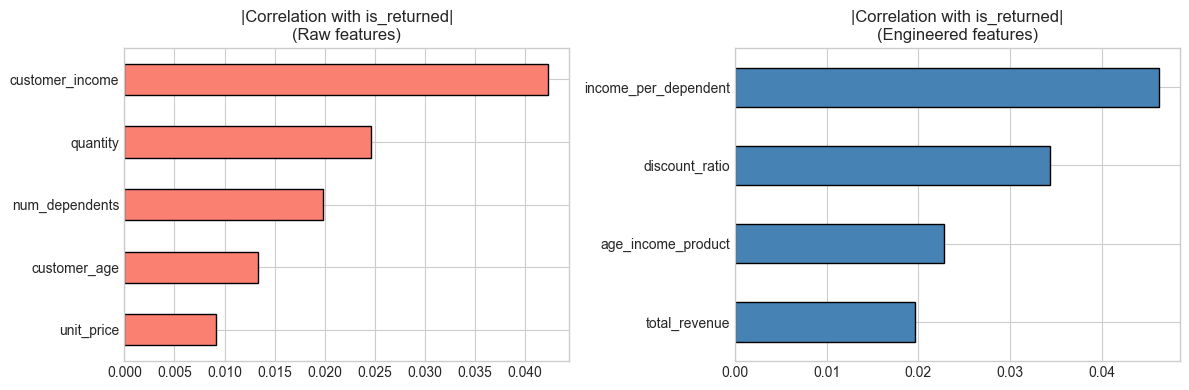

In [11]:
# Check if new features are more correlated with return rate than raw features
raw_features  = ['quantity', 'unit_price', 'customer_income', 'customer_age', 'num_dependents']
new_features  = ['total_revenue', 'income_per_dependent', 'discount_ratio', 'age_income_product']

corr_raw = df[raw_features + ['is_returned']].corr()['is_returned'].drop('is_returned').abs()
corr_new = df[new_features + ['is_returned']].corr()['is_returned'].drop('is_returned').abs()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
corr_raw.sort_values().plot(kind='barh', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('|Correlation with is_returned|\n(Raw features)')

corr_new.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('|Correlation with is_returned|\n(Engineered features)')

plt.tight_layout()
plt.show()

Compare the two charts. The raw features like quantity, unit_price, customer_age, have weak correlations with the return rate. The engineered features such as total_revenue, income_per_dependent, discount_ratio show stronger correlations. This is the value of domain-driven feature construction: a simple formula can surface a signal that was hidden in the raw columns. The model doesn't have to discover this relationship on its own; we've handed it the answer in a more usable form.

### Group-Level Aggregations : The Power of Context

Individual row features describe one transaction. But a model often needs context: what is this *customer's* typical behaviour? What is this *product's* return rate? What is the average price in this *category*?

Group-level aggregations answer these questions. We compute summary statistics (sum, mean, count, nunique) grouped by an entity (customer, product, category), then join those statistics back to each transaction row. Now every row knows not just about itself, but about the broader pattern it belongs to.

This is one of the most widely used feature engineering patterns in industry. In recommendation systems, every item gets aggregated rating statistics joined to its rows. In fraud detection, every account gets aggregated historical transaction statistics. In churn prediction, every customer gets their full purchase history summarised.

One important caution: in a time-ordered dataset, compute aggregations only from historical data before the current event. Here we use all data for simplicity, but in production you'd use a time-based rolling window.

In [15]:
# Customer-level aggregations
customer_agg = df.groupby('customer_id').agg(
    customer_total_spend    = ('total_paid', 'sum'),
    customer_order_count    = ('order_id', 'count'),
    customer_avg_order_val  = ('total_paid', 'mean'),
    customer_return_rate    = ('is_returned', 'mean'),
    customer_distinct_cats  = ('product_category', 'nunique'),
    customer_avg_quantity   = ('quantity', 'mean'),
).reset_index()

customer_agg.columns.name = None
customer_agg = customer_agg.round(2)

print('Customer-level aggregations:')
customer_agg.head(8)

Customer-level aggregations:


,customer_id,customer_total_spend,customer_order_count,customer_avg_order_val,customer_return_rate,customer_distinct_cats,customer_avg_quantity
0,1,36786.22,15,2452.42,0.00,5,10.40
1,2,25665.56,8,3208.20,0.12,3,11.50
2,3,14540.49,10,1454.05,0.30,4,7.20
3,4,13401.31,10,1340.13,0.00,5,9.50
4,5,24437.06,14,1745.50,0.21,5,9.00
5,6,10295.80,9,1143.98,0.11,4,8.44
6,7,22769.17,8,2846.15,0.00,4,11.25
7,8,35462.29,14,2533.02,0.00,5,10.57


In [17]:
# Product-level aggregations
product_agg = df.groupby('product_id').agg(
    product_popularity    = ('order_id', 'count'),
    product_avg_price     = ('unit_price', 'mean'),
    product_return_rate   = ('is_returned', 'mean'),
).reset_index().round(3)

# Category-level aggregations
category_agg = df.groupby('product_category').agg(
    category_avg_price     = ('unit_price', 'mean'),
    category_return_rate   = ('is_returned', 'mean'),
    category_order_count   = ('order_id', 'count'),
).reset_index().round(3)

# Merge all aggregations back to the main DataFrame
df_enriched = df.merge(customer_agg, on='customer_id', how='left')
df_enriched = df_enriched.merge(product_agg, on='product_id', how='left')
df_enriched = df_enriched.merge(category_agg, on='product_category', how='left')

print(f'Original columns:  {df.shape[1]}')
print(f'Enriched columns:  {df_enriched.shape[1]}')
print('\nSample enriched row:')
df_enriched[['customer_id', 'customer_total_spend', 'customer_order_count',
                    'product_popularity', 'category_return_rate']].head()

Original columns:  20
Enriched columns:  32

Sample enriched row:


,customer_id,customer_total_spend,customer_order_count,product_popularity,category_return_rate
0,103,26788.78,10,43,0.114
1,180,16048.84,11,41,0.093
2,93,45533.24,14,45,0.112
3,15,36059.20,14,40,0.071
4,107,17127.85,8,41,0.112


In [19]:
df.head()

,order_id,customer_id,product_id,product_category,quantity,unit_price,discount_pct,customer_age,customer_income,num_dependents,is_returned,order_date,total_revenue,discounted_price,total_paid,discount_amount,income_per_dependent,price_per_unit,discount_ratio,age_income_product
0,1,103,22,Toys,3,415.08,0.03,59,52462.0,0,0,2023-12-25,1245.24,402.6276,1207.8828,37.3572,52462.000000,138.360000,0.03,3095258.0
1,2,180,39,Food,8,44.69,0.25,35,34010.0,0,0,2023-08-16,357.52,33.5175,268.1400,89.3800,34010.000000,5.586250,0.25,1190350.0
2,3,93,2,Books,14,241.04,0.06,32,16363.0,2,0,2023-10-20,3374.56,226.5776,3172.0864,202.4736,5454.333333,17.217143,0.06,523616.0
3,4,15,38,Clothing,7,316.90,0.12,45,48491.0,2,0,2023-02-21,2218.30,278.8720,1952.1040,266.1960,16163.666667,45.271429,0.12,2182095.0
4,5,107,39,Books,7,415.18,0.09,50,23928.0,2,1,2023-08-28,2906.26,377.8138,2644.6966,261.5634,7976.000000,59.311429,0.09,1196400.0


We went from the original columns to many more by joining customer, product, and category aggregations back to every row. Now each transaction row knows: how much has this customer spent in total, how often do they buy, what is this product's typical return rate, and how does this category price compare to others. Every row carries the full context of the entity it belongs to, which is exactly what a model needs to make accurate predictions.

### RFM Features : A classic feature construction for Customer Value

**RFM** stands for Recency, Frequency, and Monetary that together paint a vivid picture of a customer's value and engagement.

- **Recency:** How many days since the customer last purchased? A customer who bought yesterday is far more engaged than one who last bought 18 months ago. Low recency = high engagement.
- **Frequency:** How many total purchases has this customer made? A customer with 20 orders is far more loyal than one with 1.
- **Monetary:** How much has this customer spent in total? High total spend = high lifetime value.

RFM was developed in direct marketing before machine learning existed, and it still works remarkably well. Combining all three into a score lets you segment customers into groups: Champions (recent, frequent, high spenders), At-Risk (previously active but fading), and Lost (haven't purchased in a long time).

The real power of RFM features is that they're actionable like a "Champion" customer should be rewarded and retained; an "At-Risk" customer might respond to a discount.

In [23]:
# Convert order_date to datetime first
df['order_date'] = pd.to_datetime(df['order_date'])

reference_date = df['order_date'].max() + timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency   = ('order_date',  lambda x: (reference_date - x.max()).days),
    frequency = ('order_id',   'count'),
    monetary  = ('total_paid', 'sum')).reset_index()

rfm = rfm.round(2)
print('RFM table (first 10 customers):')
rfm.head(10)

RFM table (first 10 customers):


,customer_id,recency,frequency,monetary
0,1,16,15,36786.22
1,2,39,8,25665.56
2,3,38,10,14540.49
3,4,46,10,13401.31
4,5,39,14,24437.06
5,6,3,9,10295.80
6,7,81,8,22769.17
7,8,63,14,35462.29
8,9,4,10,25160.32
9,10,19,7,12731.48


In [25]:
print('\nRFM statistics:')
rfm[['recency','frequency','monetary']].describe().round(1)


RFM statistics:


,recency,frequency,monetary
count,200.0,200.0,200.0
mean,39.6,10.0,22083.4
std,41.1,3.4,9740.7
min,1.0,3.0,3541.6
25%,11.0,8.0,14842.5
50%,27.0,10.0,20672.2
75%,54.2,12.0,27972.0
max,205.0,19.0,46612.9


RFM Segments:
segment
Loyal       71
At-Risk     46
Champion    45
Lost        38
Name: count, dtype: int64


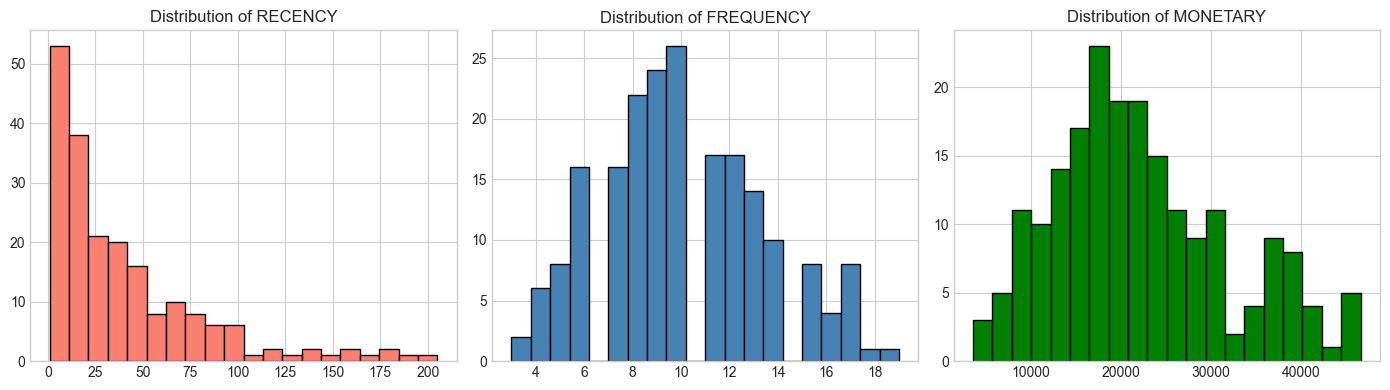

In [27]:
# RFM Scoring: assign quartile scores 1-4
# Recency: lower is better (score 4 = most recent)
# Frequency and Monetary: higher is better (score 4 = most frequent/valuable)

rfm['R_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4, 3, 2, 1]).astype(int)  # inverted
rfm['F_score'] = pd.qcut(rfm['frequency'], q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'],  q=4, labels=[1, 2, 3, 4]).astype(int)

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Segment based on RFM score
def rfm_segment(score):
    if score >= 10: return 'Champion'
    elif score >= 7: return 'Loyal'
    elif score >= 5: return 'At-Risk'
    else: return 'Lost'

rfm['segment'] = rfm['RFM_score'].apply(rfm_segment)

print('RFM Segments:')
print(rfm['segment'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['recency', 'frequency', 'monetary'], ['salmon', 'steelblue', 'green']):
    rfm[col].hist(bins=20, ax=ax, color=color, edgecolor='black')
    ax.set_title(f'Distribution of {col.upper()}')
plt.tight_layout()
plt.show()

### Binary Flags : Simple but Surprisingly Powerful

Some of the most useful features are the simplest: a binary 1/0 flag derived from a threshold condition. Is this customer in the top quartile of spenders? Is this order a bulk purchase? Has this customer ordered more than once?

Binary flags are valuable because they divide the data along a boundary that matters. A model can learn "high-value customers (flag=1) churn at 15%; all others (flag=0) churn at 35%" which would be a simple, interpretable, and powerful signal.

The threshold for a flag often comes from domain knowledge ("bulk order = more than 10 units") or from data percentiles ("high value = top 25% of spenders"). The key is that the threshold should be meaningful, not arbitrary.

In [30]:
# Merge RFM back to enriched dataframe
df_final = df_enriched.merge(rfm[['customer_id', 'RFM_score', 'segment']], on='customer_id', how='left')

# Binary flags
spend_75th = df_final['customer_total_spend'].quantile(0.75)
df_final['is_high_value_customer'] = (df_final['customer_total_spend'] > spend_75th).astype(int)
df_final['is_bulk_order']          = (df_final['quantity'] > 10).astype(int)
df_final['is_repeat_customer']     = (df_final['customer_order_count'] > 1).astype(int)
df_final['is_discounted']          = (df_final['discount_pct'] > 0).astype(int)
df_final['is_premium_product']     = (df_final['unit_price'] > df_final['unit_price'].quantile(0.75)).astype(int)

flag_cols = ['is_high_value_customer', 'is_bulk_order', 'is_repeat_customer',
             'is_discounted', 'is_premium_product']

print('Binary flag summary:')
df_final[flag_cols].mean().round(3).rename('% True')

Binary flag summary:


is_high_value_customer    0.248
is_bulk_order             0.500
is_repeat_customer        1.000
is_discounted             0.982
is_premium_product        0.250
Name: % True, dtype: float64

In [40]:
print('\nReturn rate by flag:')

for col in flag_cols:
    rate = df_final.groupby(col)['is_returned'].mean()
    rate_false = f"{rate.get(0, float('nan')):.3f}" if 0 in rate.index else 'N/A'
    rate_true  = f"{rate.get(1, float('nan')):.3f}" if 1 in rate.index else 'N/A'
    print(f'  {col}: {rate_false} (False) vs {rate_true} (True)')


Return rate by flag:
  is_high_value_customer: 0.097 (False) vs 0.079 (True)
  is_bulk_order: 0.097 (False) vs 0.088 (True)
  is_repeat_customer: N/A (False) vs 0.092 (True)
  is_discounted: 0.143 (False) vs 0.092 (True)
  is_premium_product: 0.096 (False) vs 0.082 (True)


The return rates by flag reveal some interesting patterns such as discounted orders and bulk orders tend to have different return behaviour than standard orders. Each flag cleanly divides the population into two groups with meaningfully different target rates. This is exactly what a model wants: a feature that separates high-risk from low-risk rows. Binary flags are simple to explain to stakeholders and easy to monitor in production, which makes them a first-choice tool before reaching for more complex encodings.